In [14]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy.signal
import scipy.stats
import rich
import os


plt.style.use('ncb.mplstyle')

In [15]:
root = '/Volumes/agauneu/#Data/playback'

In [16]:
# load metadata
url= 'https://docs.google.com/spreadsheets/d/e/2PACX-1vQGO1qSnt8eJDQnRTKrX7lWzUjggcabhubrwLngQbf8Ssghd243lAXItTZCjjlH7vIHgYpw3VrEz-_V/pub?gid=0&single=true&output=csv'
group_by_key = 'experiment group'
playlist_data = pd.read_csv(url)

In [17]:
groups = ['60min_IPItune_female_mel']
group = groups[0]

experiments = playlist_data[playlist_data['experiment group']==group]
experiments

,filename,empty1,empty2,notes,rig,experimenter,experiment group,subjectgroup1,genotype,date_eclosed,...,subjectgroup5,genotype.4,date_eclosed.4,sex.4,housing.4,manipulation.4,manipulation date.4,individuals.4,custom.4,Unnamed: 52
14480,localhost-20260413_111349_2,NaN,NaN,60min melanogaster playback 4s on 6s off,rpi-playback,O&J,60min_IPItune_female_mel,NaN,NM91,08.04.2026,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
14482,localhost-20260413_122510_2,NaN,NaN,60min melanogaster playback 4s on 6s off,rpi-playback,O&J,60min_IPItune_female_mel,NaN,NM91,09.04.2026,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
14484,localhost-20260413_133344_2,NaN,NaN,60min melanogaster playback 4s on 6s off,rpi-playback,O&J,60min_IPItune_female_mel,NaN,NM91,09.04.2026,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
14503,localhost-20260417_113347_2,NaN,NaN,60min melanogaster playback 4s on 6s off,rpi-playback,O&J,60min_IPItune_female_mel,NaN,NM91,13.04.2026,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
14505,localhost-20260417_131013_2,NaN,NaN,60min melanogaster playback 4s on 6s off,rpi-playback,O&J,60min_IPItune_female_mel,NaN,NM91,10.04.2026,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
14507,localhost-20260420_102449_2,NaN,NaN,60min melanogaster playback 4s on 6s off,rpi-playback,O&J,60min_IPItune_female_mel,NaN,NM91,16.04.2026,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
14509,localhost-20260420_113459_2,NaN,NaN,60min melanogaster playback 4s on 6s off,rpi-playback,O&J,60min_IPItune_female_mel,NaN,NM91,15.04.2026,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
14513,localhost-20260422_102114_2,NaN,NaN,60min melanogaster playback 4s on 6s off,rpi-playback,O&J,60min_IPItune_female_mel,NaN,NM91,17.04.2026,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [18]:
all_traces = []
all_logs = []
for experiment in experiments['filename']:
    videoname = experiment
    # if '20260413' in experiment:
    #     continue
    if experiment == 'localhost-20260413_122510_2' or experiment == 'localhost-20260413_122510':
        continue
    if not isinstance(videoname, str):
        continue
    print(experiment)
    datename = videoname[:-2] if videoname.endswith('_2') else videoname
    npz_file = f"{root}/res/{datename}/{videoname}_spd.npz"
    csv_file = f"{root}/res/{datename}/{videoname}_playlist.csv"

    if not os.path.exists(csv_file):
        print(f'SKIPPING {experiment}')
    else:
        logs = pd.read_csv(csv_file)
        all_logs.append(logs)

        d = np.load(npz_file)
        all_traces.extend(d['traces'])

# hoping time is the same for all
time = d['time']
del d

logs = pd.concat(all_logs)
logs['traces'] = all_traces
logs

localhost-20260413_111349_2
localhost-20260413_133344_2
localhost-20260417_113347_2
localhost-20260417_131013_2
localhost-20260420_102449_2
localhost-20260420_113459_2
localhost-20260422_102114_2


,sessionname,videoname,chamber_id,timestamp,rig,cnt,stimFileName,silencePre,silencePost,delayPost,intensity,freq,MODE,onset_times,offset_times,traces
0,localhost-20260413_111349,localhost-20260413_111349_2,chamber01,2026-04-13T11:14:01.150000,DAQ@PC-845393,1,meltune_ipi38_pulseTrain_PDUR16ms_PCAR250hz_PP...,30000,30000,0,6.0,250.0,[nan],30.969469,34.930478,"[0.0027327327858994556, 0.002733058576642678, ..."
1,localhost-20260413_111349,localhost-20260413_111349_2,chamber01,2026-04-13T11:15:03.741000,DAQ@PC-845393,2,meltune_ipi130_pulseTrain_PDUR16ms_PCAR250hz_P...,30000,30000,0,6.0,250.0,[nan],94.961616,98.740627,"[9.067137488344482e-05, 9.067137488344482e-05,..."
2,localhost-20260413_111349,localhost-20260413_111349_2,chamber01,2026-04-13T11:16:07.743000,DAQ@PC-845393,3,meltune_ipi70_pulseTrain_PDUR16ms_PCAR250hz_PP...,30000,30000,0,6.0,250.0,[nan],158.863764,162.792773,"[2.1030337687747676e-06, 2.1030337652287417e-0..."
3,localhost-20260413_111349,localhost-20260413_111349_2,chamber01,2026-04-13T11:17:11.745000,DAQ@PC-845393,4,meltune_ipi38_pulseTrain_PDUR16ms_PCAR250hz_PP...,30000,30000,0,6.0,250.0,[nan],222.855912,226.816920,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
4,localhost-20260413_111349,localhost-20260413_111349_2,chamber01,2026-04-13T11:18:15.747000,DAQ@PC-845393,5,meltune_ipi130_pulseTrain_PDUR16ms_PCAR250hz_P...,30000,30000,0,6.0,250.0,[nan],286.848058,290.627066,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
555,localhost-20260422_102114,localhost-20260422_102114_2,chamber10,2026-04-22T11:15:45.941000,DAQ@PC-845393,52,meltune_ipi38_pulseTrain_PDUR16ms_PCAR250hz_PP...,30000,30000,0,6.0,250.0,[nan],3292.396365,3296.356367,"[0.0004277723781209246, 0.00042772138609838644..."
556,localhost-20260422_102114,localhost-20260422_102114_2,chamber10,2026-04-22T11:16:49.934000,DAQ@PC-845393,53,meltune_ipi130_pulseTrain_PDUR16ms_PCAR250hz_P...,30000,30000,0,6.0,250.0,[nan],3356.386435,3360.164442,"[0.003636125571781292, 0.003636125571781292, 0..."
557,localhost-20260422_102114,localhost-20260422_102114_2,chamber10,2026-04-22T11:17:53.835000,DAQ@PC-845393,54,meltune_ipi70_pulseTrain_PDUR16ms_PCAR250hz_PP...,30000,30000,0,6.0,250.0,[nan],3420.285529,3424.213754,"[3.903371889241301e-06, 4.5602665019963535e-06..."
558,localhost-20260422_102114,localhost-20260422_102114_2,chamber10,2026-04-22T11:18:57.842000,DAQ@PC-845393,55,meltune_ipi38_pulseTrain_PDUR16ms_PCAR250hz_PP...,30000,30000,0,6.0,250.0,[nan],3484.275956,3488.235915,"[0.001581964906732143, 0.00023083515130728333,..."


,sessionname,videoname,chamber_id,timestamp,rig,cnt,stimFileName,silencePre,silencePost,delayPost,intensity,freq,MODE,onset_times,offset_times,traces


,sessionname,videoname,chamber_id,timestamp,rig,cnt,stimFileName,silencePre,silencePost,delayPost,intensity,freq,MODE,onset_times,offset_times,traces


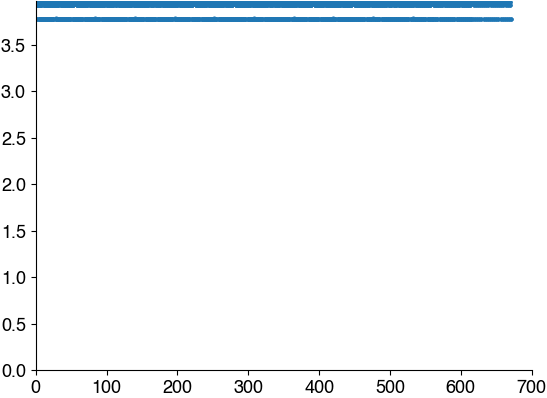

In [19]:
plt.plot(logs.offset_times-logs.onset_times, '.')
plt.ylim(0)
# logs[logs.offset_times-logs.onset_times>4.5]
display(logs[logs.offset_times-logs.onset_times>4.2])
display(logs[logs.offset_times-logs.onset_times<3.6])

Text(0.5, 0, 'Durations [s]')

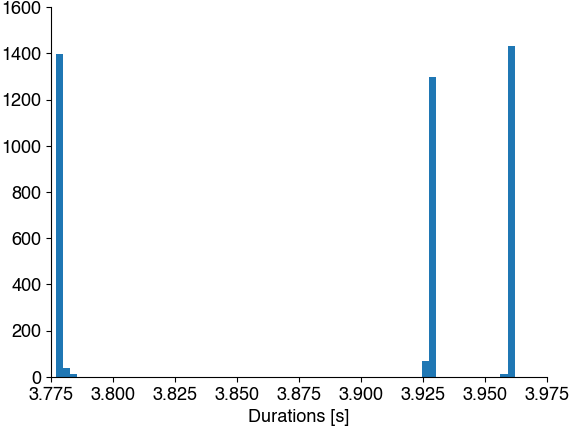

In [20]:
plt.hist(logs.offset_times-logs.onset_times, bins=64)
plt.xlabel('Durations [s]')

In [21]:
stimuli = logs.groupby(['stimFileName', 'intensity', 'silencePre', 'silencePost', 'delayPost', 'freq'], sort=True)
rich.print(list(stimuli.groups.keys()))

individuals = logs.groupby(['rig', 'chamber_id', 'sessionname', 'videoname'], sort=True)
rich.print(list(individuals.groups.keys())[:10])

logs['individual_id'] = individuals.ngroup()
logs['stimulus_id'] = stimuli.ngroup()
logs.head()


[
    ('meltune_ipi130_pulseTrain_PDUR16ms_PCAR250hz_PPAU114ms_TDUR4s_NPUL30.wav', 6.0, 30000, 30000, 0, 250.0),
    ('meltune_ipi38_pulseTrain_PDUR16ms_PCAR250hz_PPAU22ms_TDUR4s_NPUL105.wav', 6.0, 30000, 30000, 0, 250.0),
    ('meltune_ipi70_pulseTrain_PDUR16ms_PCAR250hz_PPAU54ms_TDUR4s_NPUL57.wav', 6.0, 30000, 30000, 0, 250.0)
]

[
    ('DAQ@PC-845393', 'chamber01', 'localhost-20260413_111349', 'localhost-20260413_111349_2'),
    ('DAQ@PC-845393', 'chamber01', 'localhost-20260413_133344', 'localhost-20260413_133344_2'),
    ('DAQ@PC-845393', 'chamber01', 'localhost-20260417_113347', 'localhost-20260417_113347_2'),
    ('DAQ@PC-845393', 'chamber01', 'localhost-20260417_131013', 'localhost-20260417_131013_2'),
    ('DAQ@PC-845393', 'chamber01', 'localhost-20260420_102449', 'localhost-20260420_102449_2'),
    ('DAQ@PC-845393', 'chamber01', 'localhost-20260420_113459', 'localhost-20260420_113459_2'),
    ('DAQ@PC-845393', 'chamber01', 'localhost-20260422_102114', 'localhost-20260422_102114_2'),
    ('DAQ@PC-845393', 'chamber02', 'localhost-20260413_111349', 'localhost-20260413_111349_2'),
    ('DAQ@PC-845393', 'chamber02', 'localhost-20260413_133344', 'localhost-20260413_133344_2'),
    ('DAQ@PC-845393', 'chamber02', 'localhost-20260417_113347', 'localhost-20260417_113347_2')
]

,sessionname,videoname,chamber_id,timestamp,rig,cnt,stimFileName,silencePre,silencePost,delayPost,intensity,freq,MODE,onset_times,offset_times,traces,individual_id,stimulus_id
0,localhost-20260413_111349,localhost-20260413_111349_2,chamber01,2026-04-13T11:14:01.150000,DAQ@PC-845393,1,meltune_ipi38_pulseTrain_PDUR16ms_PCAR250hz_PP...,30000,30000,0,6.0,250.0,[nan],30.969469,34.930478,"[0.0027327327858994556, 0.002733058576642678, ...",0,1
1,localhost-20260413_111349,localhost-20260413_111349_2,chamber01,2026-04-13T11:15:03.741000,DAQ@PC-845393,2,meltune_ipi130_pulseTrain_PDUR16ms_PCAR250hz_P...,30000,30000,0,6.0,250.0,[nan],94.961616,98.740627,"[9.067137488344482e-05, 9.067137488344482e-05,...",0,0
2,localhost-20260413_111349,localhost-20260413_111349_2,chamber01,2026-04-13T11:16:07.743000,DAQ@PC-845393,3,meltune_ipi70_pulseTrain_PDUR16ms_PCAR250hz_PP...,30000,30000,0,6.0,250.0,[nan],158.863764,162.792773,"[2.1030337687747676e-06, 2.1030337652287417e-0...",0,2
3,localhost-20260413_111349,localhost-20260413_111349_2,chamber01,2026-04-13T11:17:11.745000,DAQ@PC-845393,4,meltune_ipi38_pulseTrain_PDUR16ms_PCAR250hz_PP...,30000,30000,0,6.0,250.0,[nan],222.855912,226.816920,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",0,1
4,localhost-20260413_111349,localhost-20260413_111349_2,chamber01,2026-04-13T11:18:15.747000,DAQ@PC-845393,5,meltune_ipi130_pulseTrain_PDUR16ms_PCAR250hz_P...,30000,30000,0,6.0,250.0,[nan],286.848058,290.627066,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",0,0


In [22]:
import xarray as xr

data = np.stack(all_traces).T

ds = xr.Dataset({'speed': (('time', 'trial'), data),
                 'speed_raw': (('time', 'trial'), data),
                 'baseline': (('trial'), np.nanmean(data[time<0, :], axis=0)),
                 'response': (('trial'), np.nanmean(data[time>0, :], axis=0)),
                 },
                coords={'time': time,
                        'stimulus': ('trial', logs['stimulus_id']),
                        'individual': ('trial', logs['individual_id'])
                        }
                )
ds['speed'] = ds.speed - ds.baseline

ds

<xarray.Dataset> Size: 1GB
Dimensions:     (time: 15000, trial: 4256)
Coordinates:
  * time        (time) float64 120kB -5.0 -4.999 -4.998 ... 9.997 9.998 9.999
    stimulus    (trial) int64 34kB 1 0 2 1 0 2 1 0 2 1 0 ... 0 2 1 0 2 1 0 2 1 0
    individual  (trial) int64 34kB 0 0 0 0 0 0 0 0 0 ... 66 66 66 66 66 66 66 66
Dimensions without coordinates: trial
Data variables:
    speed       (time, trial) float64 511MB -0.0005793 -0.003973 ... 0.002172
    speed_raw   (time, trial) float64 511MB 0.002733 9.067e-05 ... 0.005564
    baseline    (trial) float64 34kB 0.003312 0.004064 ... 0.00315 0.003392
    response    (trial) float64 34kB 0.003616 0.002454 ... 0.005714 0.005779

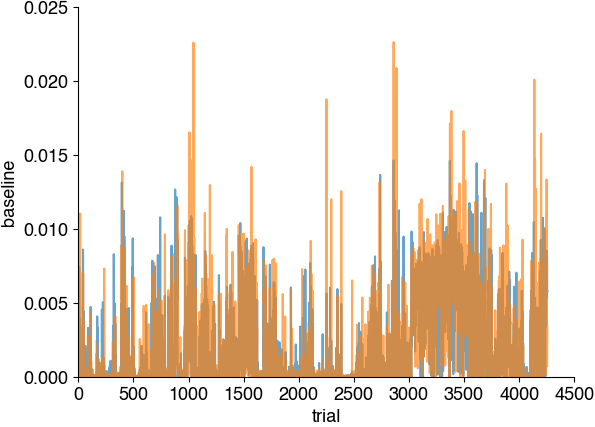

In [23]:
MIN_SPEED = 0.001
ds.response.plot(alpha=0.67)
ds.baseline.plot(alpha=0.67)

<xarray.DataArray 'speed' (time: 15000, z: 228)> Size: 27MB
array([[ 4.06963521e-03,  3.56959248e-03, -6.05222313e-04, ...,
        -2.62212464e-05, -7.17646667e-05, -1.43068019e-03],
       [ 3.97405798e-03,  3.48402743e-03, -5.99590196e-04, ...,
        -2.57403390e-05, -7.13182896e-05, -1.43312701e-03],
       [ 3.88220358e-03,  3.40173315e-03, -5.94214581e-04, ...,
        -2.52780223e-05, -7.08890808e-05, -1.43543638e-03],
       ...,
       [-1.43645431e-03, -1.31921364e-03, -9.03661916e-04, ...,
        -1.71514907e-04, -1.59917623e-04,  4.09791360e-04],
       [-1.44022592e-03, -1.31689200e-03, -9.10450383e-04, ...,
        -1.71353273e-04, -1.59204015e-04,  3.22281642e-04],
       [-1.44414544e-03, -1.31447932e-03, -9.17361750e-04, ...,
        -1.71183868e-04, -1.58463924e-04,  2.31534355e-04]],
      shape=(15000, 228))
Coordinates:
  * time        (time) float64 120kB -5.0 -4.999 -4.998 ... 9.997 9.998 9.999
  * z           (z) object 2kB MultiIndex
  * stimulus    (z) int64 2kB 0 0 0 0 0 0 0 0 0 0 0 0 ... 2 2 2 2 2 2 2 2 2 2 2
  * individual  (z) int64 2kB 0 1 2 3 4 5 6 7 8 9 ... 67 68 69 70 71 72 73 74 75

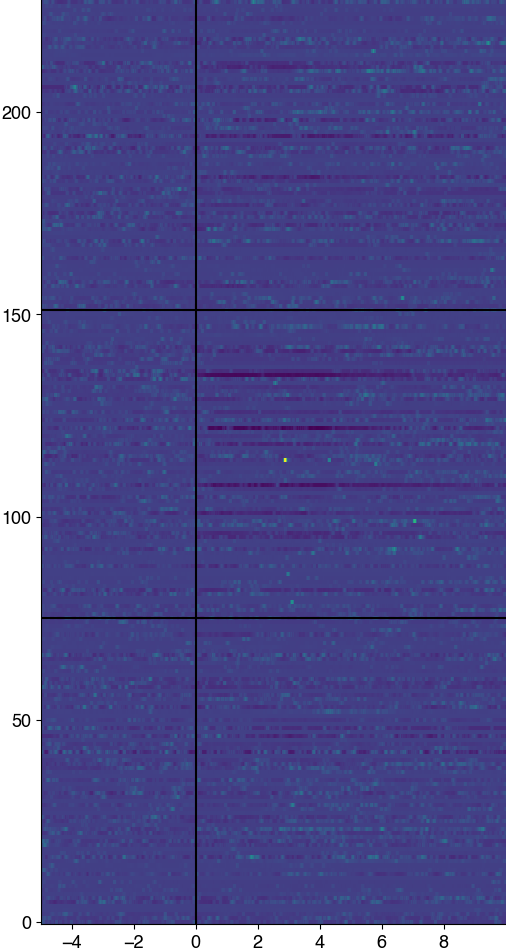

In [24]:
# ds_si = ds.speed[:, ds.baseline>MIN_SPEED].groupby(['stimulus', 'individual']).mean().stack(z=("stimulus", "individual"))
ds_si = ds.speed.groupby(['stimulus', 'individual']).mean().stack(z=("stimulus", "individual"))
ds_si = ds_si.rolling(time=100, min_periods=20, center=True).mean()
display(ds_si)

stim_change_points = np.where(np.diff(ds_si.stimulus)!=0)[0]

plt.figure(figsize=(6, 12))
plt.pcolormesh(ds_si.time, range(ds_si.shape[1]), ds_si.T)
plt.xlim(ds_si.time[0], ds_si.time[-1])
plt.ylim(-0.5, ds_si.shape[1]-0.5)
plt.axvline(0, c='k')
[plt.axhline(scp, c='k') for scp in stim_change_points]
plt.show()

<xarray.DataArray 'speed' (time: 15000, stimulus: 3)> Size: 360kB
array([[ 2.88340366e-04,  8.29506006e-05,  5.93239429e-05],
       [ 2.86966159e-04,  8.29632791e-05,  5.88966734e-05],
       [ 2.85352663e-04,  8.25972847e-05,  5.83618409e-05],
       ...,
       [-4.31058298e-05, -6.81031809e-05,  9.83056501e-05],
       [-4.20297597e-05, -6.97500804e-05,  9.68318274e-05],
       [-4.12352387e-05, -7.15019528e-05,  9.55574607e-05]],
      shape=(15000, 3))
Coordinates:
  * time      (time) float64 120kB -5.0 -4.999 -4.998 ... 9.997 9.998 9.999
  * stimulus  (stimulus) int64 24B 0 1 2

(-5.0, 9.999)

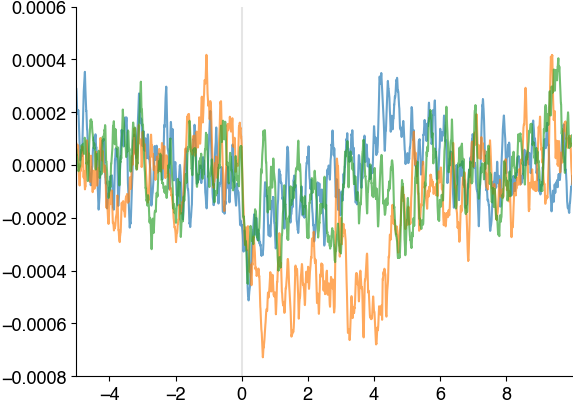

In [25]:
# das = ds.speed[:, ds.baseline>MIN_SPEED].groupby('stimulus').mean().rolling(time=100, min_periods=33, center=True).mean()
das = ds.speed[:].groupby('stimulus').mean().rolling(time=100, min_periods=33, center=True).mean()
display(das)

plt.axvline(0, c='k', alpha=0.1)
plt.plot(das.time, das, alpha=0.67)
plt.xlim(das.time[0], das.time[-1])

<>:11: SyntaxWarning: "\D" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\D"? A raw string is also an option.
<>:11: SyntaxWarning: "\D" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\D"? A raw string is also an option.
/var/folders/zr/6ql4dzjx0tq8mpzht_2dwh480000gn/T/ipykernel_75224/3122091031.py:11: SyntaxWarning: "\D" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\D"? A raw string is also an option.
  plt.ylabel('$\Delta$speed \n [px/frame I think]')


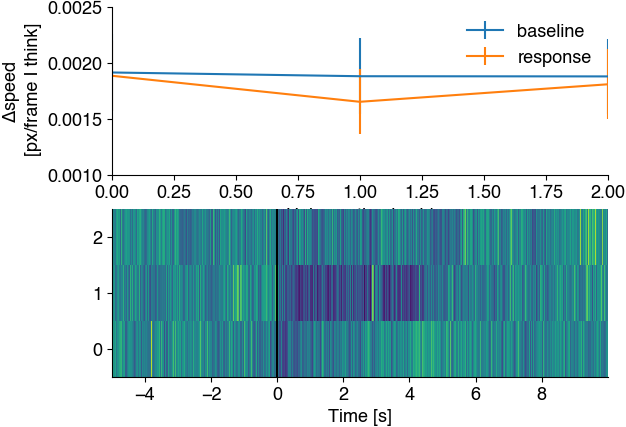

In [26]:
dsa = ds.groupby('stimulus').mean()
dsa_std = ds.groupby('stimulus').std()
dsa_sem = dsa_std / np.sqrt(len(np.unique(ds.individual)))

plt.subplot(211)
plt.errorbar(dsa.stimulus, dsa.baseline, yerr=dsa_sem.baseline, label='baseline')
plt.errorbar(dsa.stimulus, dsa.response, yerr=dsa_sem.response, label='response')
plt.legend()
plt.xlim(0)
plt.xlabel('Unique stimulus id')
plt.ylabel('$\Delta$speed \n [px/frame I think]')

plt.subplot(212)
plt.pcolormesh(dsa.time, range(dsa.speed.shape[0]), dsa.speed)
plt.xlim(dsa.time[0], dsa.time[-1])
plt.ylim(-0.5, dsa.speed.shape[0]-0.5)
plt.xlabel("Time [s]")
plt.axvline(0, c='k')
plt.show()